In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
from IPython.display import display, Markdown

from nltk import sentiment
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk import tokenize

from textblob import TextBlob

import tensorflow as tf
import sklearn
from tqdm import tqdm
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import InputExample, InputFeatures

import math, os
from typing import *

import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram

/opt/conda/lib/python3.7/site-packages/nltk/twitter/__init__.py:20: UserWarning: The twython library has not been installed. Some functionality from the twitter package will not be available.
  warnings.warn("The twython library has not been installed. "


# Sentiment Analysis

In this lab, we will use sentiment analysis tools to improve our understanding of our poems and novels. We will begin by examining the sentiment of the lines of our poems. We will then apply sentiment analysis to identify key sentences in our novels, to plot a sentiment trajectory for our novel, and to compare sentiment trajectories between novels.

We will be using the following sentiment analysis tools:
* Simple model trained from IMDB
* BERT
  * This is a very large sentiment analysis model, which we will load in the code block that follows.
* VADER
* TextBlob

Add the Novels and Poems data sets to the notebook prior to running any of the code blocks.

In [2]:
# Functions from Lab 2

## file_dictionary() ##
def file_dictionary(file_path: str) -> Dict[str,str]:
    content = {}
    for dirname, _, filenames in os.walk(file_path):
        for filename in filenames:
            poem_open = open(os.path.join(dirname, filename)).read()
            content[filename] = poem_open
    return content

## all_tokens_from() ##
def all_tokens_from(text: str) -> List[str]:
    tokens = []
    for token in re.findall(r'\b\w+\b', text.lower()):
        tokens.append(token)
    return tokens


In [3]:
bert_model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model.load_weights('/kaggle/input/bert-sentiment-analysis-imdb/sentiment_bert_model')

def bert_score(text: str) -> float:
    tf_batch = tokenizer(text, max_length=len(text), padding=True, truncation=True, return_tensors='tf')   # we are tokenizing before sending into our trained model
    tf_outputs = bert_model(tf_batch)                                  
    tf_predictions = tf.nn.softmax(tf_outputs[0], axis=-1)       # axis=-1, this means that the index that will be returned by argmax will be taken from the *last* axis.
    return tf.get_static_value(tf_predictions[0][1] - tf_predictions[0][0])

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/511M [00:00<?, ?B/s]


User settings:

   KMP_AFFINITY=granularity=fine,noverbose,compact,1,0
   KMP_BLOCKTIME=0
   KMP_DUPLICATE_LIB_OK=True
   KMP_INIT_AT_FORK=FALSE
   KMP_SETTINGS=1
   KMP_WARNINGS=0

Effective settings:

   KMP_ABORT_DELAY=0
   KMP_ADAPTIVE_LOCK_PROPS='1,1024'
   KMP_ALIGN_ALLOC=64
   KMP_ALL_THREADPRIVATE=128
   KMP_ATOMIC_MODE=2
   KMP_BLOCKTIME=0
   KMP_CPUINFO_FILE: value is not defined
   KMP_DETERMINISTIC_REDUCTION=false
   KMP_DEVICE_THREAD_LIMIT=2147483647
   KMP_DISP_NUM_BUFFERS=7
   KMP_DUPLICATE_LIB_OK=true
   KMP_ENABLE_TASK_THROTTLING=true
   KMP_FORCE_REDUCTION: value is not defined
   KMP_FOREIGN_THREADS_THREADPRIVATE=true
   KMP_FORKJOIN_BARRIER='2,2'
   KMP_FORKJOIN_BARRIER_PATTERN='hyper,hyper'
   KMP_GTID_MODE=3
   KMP_HANDLE_SIGNALS=false
   KMP_HOT_TEAMS_MAX_LEVEL=1
   KMP_HOT_TEAMS_MODE=0
   KMP_INIT_AT_FORK=true
   KMP_LIBRARY=throughput
   KMP_LOCK_KIND=queuing
   KMP_MALLOC_POOL_INCR=1M
   KMP_NUM_LOCKS_IN_BLOCK=1
   KMP_PLAIN_BARRIER='2,2'
   KMP_PLAIN_BARRIER

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/455k [00:00<?, ?B/s]

In [4]:
def show_markdown_table(headers: List[str], data: List) -> str:
    s = f"| {' | '.join(headers)} |\n| {' | '.join([(max(1, len(header) - 1)) * '-' + ':' for header in headers])} |\n"
    for row in data:
        s += f"| {' | '.join([str(item) for item in row])} |\n"
    display(Markdown(s))

In [5]:
def assess(value, expected):
    print(value)
    return value == expected

# A Simple Sentiment Analysis Model

We can build a very simple sentiment analysis model using the Internet Movie Review Database. By annotating each word with the average score of the movie reviews in which it appears, we can rate the sentiment of a word. By averaging the sentiment values in a sentence or other lexical unit, we can rate the sentiment of that unit.

First, write a block of code that opens the file `/kaggle/input/cleveland-data/movieReviews.txt` and creates a dictionary `word_ratings` as follows:
* Set up two dictionaries
  * Total ratings of words
  * Total counts of words
* For each line in the file
  * Find out the rating (0-4) from the first character.
  * Shift the line to lower case.
  * Split the line, and add all its words to a `set()`.
  * For each word in the set
    * Add the current rating to its total rating
    * Increment its current count by one
* For each word found in the file
  * Create an entry in `word_ratings` representing the average rating for that word, by dividing its total rating by its total count.

In [6]:
word_ratings = {
    'total_ratings': {},
    'total_counts': {}
}

with open('/kaggle/input/cleveland-data/movieReviews.txt', 'r') as file:
    for line in file:
        rating = int(line[0])
        words = set(line[1:].lower().split())
        
        for word in words:
            word_ratings['total_ratings'][word] = word_ratings['total_ratings'].get(word, 0) + rating
            word_ratings['total_counts'][word] = word_ratings['total_counts'].get(word, 0) + 1

for word, total_rating in word_ratings['total_ratings'].items():
    total_count = word_ratings['total_counts'][word]
    word_ratings[word] = total_rating / total_count

In [7]:
ratings = [(word, word_ratings[word]) for word in ('duck', 'good', 'bad', 'mystery')]
assess(ratings, [('duck', 2.5), ('good', 2.1944444444444446), ('bad', 0.9395973154362416), ('mystery', 1.9655172413793103)])

[('duck', 2.5), ('good', 2.1944444444444446), ('bad', 0.9395973154362416), ('mystery', 1.9655172413793103)]


True

This is the tester you told me to put below

In [8]:
ratings = [(word, word_ratings[word]) for word in ('my', 'was', 'not', 'very', 'tasty', 'this', 'morning')]
assess(ratings, [('my', 2.0625), ('was', 1.6815286624203822), ('not', 1.9213286713286712), ('very', 2.111111111111111), ('tasty', 2.375), ('this', 1.9630010277492291), ('morning', 1.6666666666666667)])

[('my', 2.0625), ('was', 1.6815286624203822), ('not', 1.9213286713286712), ('very', 2.111111111111111), ('tasty', 2.375), ('this', 1.9630010277492291), ('morning', 1.6666666666666667)]


True

Now write the function `simple_sentiment()`. For a given lexical unit, it will call `all_tokens_from()` to break it up into tokens. It will next calculate the sum of all the ratings for each word that is present in `word_ratings`. Because the average ratings range from 0 to 4, and we want to standardize sentiment values in the range from -1 to 1, subtract 2 from the result, then divide by 2.

In [9]:
import re
def simple_sentiment(lexical_unit: str) -> float:
    tokens = all_tokens_from(lexical_unit)
    total_score = 0
    count = 0 
    
    for token in tokens:
        if token in word_ratings:
            total_score += word_ratings[token]
            count += 1
            #print(token)
            
    if count > 0:
        sentiment = (total_score / count - 2) / 2 
    else:
        sentiment = 0  
    return sentiment


In [10]:
assess(simple_sentiment("My breakfast was not very tasty this morning."), -0.01563313290885293)

-0.01563313290885293


True

# Poem Sentiment

All three tools rate sentiment on a scale from -1 to 1. `VADER` also breaks down subscores of positive and negative sentiment. `TextBlob` has a `polarity` subscore to rate the sentiment, and a `subjectivity` subscore where 0 represents an objective statement and 1 represents a statement of pure opinion. Run the code below to view the sentiment scores for each line of your poem. Then answer the questions that follow.

In [11]:
# Replace the filename below with the filename of your poem
poem = open('/kaggle/input/poems-hendrix-csci-270-spring-2024/Frost_RoadNotTaken_Hamilton.txt').read()
poem_lines_list = poem.split('\n')
poem_lines_list

['The Road Not Taken',
 '',
 'By Robert Lee Frost',
 '',
 '',
 'Two roads diverged in a yellow wood,',
 'And sorry I could not travel both',
 'And be one traveler, long I stood',
 'And looked down one as far as I could',
 'To where it bent in the undergrowth;',
 '',
 'Then took the other, as just as fair',
 'And having perhaps the better claim,',
 'Because it was grassy and wanted wear;',
 'Though as for that, the passing there',
 'Had worn them really about the same,',
 '',
 'And both that morning equally lay',
 'In leaves no step had trodden black',
 'Oh, I kept the first for another day!',
 'Yet knowing how way leads on to way,',
 'I doubted if I should ever come back.',
 '',
 'I shall be telling this with a sigh',
 'Somewhere ages and ages hence:',
 'Two roads diverged in a wood, and I,',
 'I took the one less traveled by,',
 'And that has made all the difference.']

In [12]:
vader = SentimentIntensityAnalyzer()

headers = ['Line', 'Simple', 'BERT', 'VADER', 'TextBlob']
rows = [[line,
         simple_sentiment(line),
         bert_score(line), 
         vader.polarity_scores(line), 
         TextBlob(line).sentiment] 
        for line in poem_lines_list]
show_markdown_table(headers, rows)

| Line | Simple | BERT | VADER | TextBlob |
| ---: | -----: | ---: | ----: | -------: |
| The Road Not Taken | 0.025361289059389724 | 0.5680107 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
|  | 0 | 0.7844378 | {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| By Robert Lee Frost | 0.19215409913084325 | 0.99299604 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
|  | 0 | 0.7844378 | {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
|  | 0 | 0.7844378 | {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| Two roads diverged in a yellow wood, | -0.21526237443141072 | 0.69182974 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| And sorry I could not travel both | -0.0025217762126198418 | -0.67409515 | {'neg': 0.206, 'neu': 0.794, 'pos': 0.0, 'compound': -0.0772} | Sentiment(polarity=-0.5, subjectivity=1.0) |
| And be one traveler, long I stood | -0.06436539232950811 | 0.93418884 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=-0.05, subjectivity=0.4) |
| And looked down one as far as I could | -0.06917733405522719 | -0.95585316 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=-0.02777777777777779, subjectivity=0.6444444444444445) |
| To where it bent in the undergrowth; | -0.015681035517965736 | -0.04071331 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
|  | 0 | 0.7844378 | {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| Then took the other, as just as fair | -0.027737257231986723 | 0.69446087 | {'neg': 0.0, 'neu': 0.753, 'pos': 0.247, 'compound': 0.3182} | Sentiment(polarity=0.2875, subjectivity=0.6375) |
| And having perhaps the better claim, | -0.11187738057749874 | 0.31513184 | {'neg': 0.0, 'neu': 0.633, 'pos': 0.367, 'compound': 0.4404} | Sentiment(polarity=0.5, subjectivity=0.5) |
| Because it was grassy and wanted wear; | -0.034914148699178305 | -0.9267763 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| Though as for that, the passing there | -0.039831640005496216 | 0.05076608 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| Had worn them really about the same, | -0.039857073101015605 | -0.13157684 | {'neg': 0.268, 'neu': 0.732, 'pos': 0.0, 'compound': -0.296} | Sentiment(polarity=0.1, subjectivity=0.1625) |
|  | 0 | 0.7844378 | {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| And both that morning equally lay | 0.05177423371393064 | 0.54510605 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.25) |
| In leaves no step had trodden black | -0.019045990980933514 | -0.8706791 | {'neg': 0.268, 'neu': 0.732, 'pos': 0.0, 'compound': -0.296} | Sentiment(polarity=-0.16666666666666666, subjectivity=0.43333333333333335) |
| Oh, I kept the first for another day! | 0.0093751220024747 | -0.8503531 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.3125, subjectivity=0.3333333333333333) |
| Yet knowing how way leads on to way, | 0.03586432957594843 | 0.8834243 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| I doubted if I should ever come back. | -0.03937610408871639 | 0.30084848 | {'neg': 0.296, 'neu': 0.704, 'pos': 0.0, 'compound': -0.2732} | Sentiment(polarity=0.0, subjectivity=0.0) |
|  | 0 | 0.7844378 | {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| I shall be telling this with a sigh | 0.011237407456041959 | -0.013942003 | {'neg': 0.0, 'neu': 0.82, 'pos': 0.18, 'compound': 0.0258} | Sentiment(polarity=0.0, subjectivity=0.0) |
| Somewhere ages and ages hence: | 0.36880246142357587 | 0.47328714 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| Two roads diverged in a wood, and I, | -0.14827046987346482 | 0.549575 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |
| I took the one less traveled by, | 0.03876319319213328 | -0.6267732 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=-0.16666666666666666, subjectivity=0.06666666666666667) |
| And that has made all the difference. | 0.028518113984191462 | 0.9527593 | {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0} | Sentiment(polarity=0.0, subjectivity=0.0) |


Examine each line of your poem. 

1. How accurately did `simple_sentiment()` rate each line of your poem? 

It wasn't the best. My simple_sentiment() works, but not that accurately. It produces different numbers than Bert, Vader, and TextBlob. For most of my senteces it is in the same ballpark as Bert, but there are a few exceptions

2. How about `BERT`?

I feel like BERT is the most accurate of the sentiment analyzers because it takes into account the most information. Judging by the scores and my personal rating of the sentencs, BERT seems to have the best analysis.

3. How about `VADER`? 

Vader was neutral for a lot of the meaningless lines (which is accurate), but it also provided good, accurate analysis of the text. I liked it and it was one of the best

4. How about `TextBlob`?

Textblob also ignored a lot of the neutral lines in the poem and accurately scores  the sentiment of the text.

5. Was one of them preferable overall? Explain.

I mean I enjoyed simple_sentiment() because I coded it myself and it is satisfying see your work, but functionality-wise bert was the most accurate because it accounts for the most factors.

6. What insights did you gain about the flow of emotional impact of your poem by employing sentiment analysis?

I feel like "The Road Not Taken" might not accurately analyzed because there are sentences (lines) in the poem that do not have any significant meaning and are pretty convoluted, yet they still have strong scores. The flow was pretty consistent throughout and overall positive.

# Novel Sentiment

To prepare to analyze the sentiments of your novel, copy your sentence-identifying function from Lab 2 into the code box below. Modify it as follows:
* The function should return a list of strings, where each sentence is a single string.
* Each sentence should retain its punctuation and capitalization.


In [13]:
def all_sentences_from(text: str) -> List[str]:
    list_sentences = []
    sentence = ""
    decimal_flag = False  
    for i, char in enumerate(text):
        if char in '.!?':
            next_char = text[i + 1] if i + 1 < len(text) else None
            if next_char and next_char.isdigit():
                sentence += char
            else:
                sentence += char
                list_sentences.append(sentence.strip())
                sentence = ""
        else:
            sentence += char
    if sentence.strip():
        list_sentences.append(sentence.strip())
        
    return list_sentences

In [14]:
test_text = "This paper describes the development, validation, and evaluation of VADER (for Valence Aware Dictionary for sEntiment Reasoning). We use a combination of qualitative and quantitative methods to produce, and then empirically validate, a gold-standard sentiment lexicon that is especially attuned to microblog-like contexts. We next combine these lexical features with consideration for five generalizable rules that embody grammatical and syntactical conventions that humans use when expressing or emphasizing sentiment intensity. We find that incorporating these heuristics improves the accuracy of the sentiment analysis engine across several domain contexts (social media text, NYTimes editorials, movie reviews, and product reviews). Interestingly, the VADER lexicon performs exceptionally well in the social media domain. The correlation coefficient shows that VADER (r = 0.881) performs as well as individual human raters (r = 0.888) at matching ground truth (aggregated group mean from 20 human raters for sentiment intensity of each tweet). Surprisingly, when we further inspect the classification accuracy, we see that VADER (F1 = 0.96) actually even outperforms individual human raters (F1 = 0.84) at correctly classifying the sentiment of tweets into positive, neutral, or negative classes. "

In [15]:
assess(all_sentences_from(test_text), ['This paper describes the development, validation, and evaluation of VADER (for Valence Aware Dictionary for sEntiment Reasoning).',
 'We use a combination of qualitative and quantitative methods to produce, and then empirically validate, a gold-standard sentiment lexicon that is especially attuned to microblog-like contexts.',
 'We next combine these lexical features with consideration for five generalizable rules that embody grammatical and syntactical conventions that humans use when expressing or emphasizing sentiment intensity.',
 'We find that incorporating these heuristics improves the accuracy of the sentiment analysis engine across several domain contexts (social media text, NYTimes editorials, movie reviews, and product reviews).',
 'Interestingly, the VADER lexicon performs exceptionally well in the social media domain.',
 'The correlation coefficient shows that VADER (r = 0.881) performs as well as individual human raters (r = 0.888) at matching ground truth (aggregated group mean from 20 human raters for sentiment intensity of each tweet).',
 'Surprisingly, when we further inspect the classification accuracy, we see that VADER (F1 = 0.96) actually even outperforms individual human raters (F1 = 0.84) at correctly classifying the sentiment of tweets into positive, neutral, or negative classes.'])

['This paper describes the development, validation, and evaluation of VADER (for Valence Aware Dictionary for sEntiment Reasoning).', 'We use a combination of qualitative and quantitative methods to produce, and then empirically validate, a gold-standard sentiment lexicon that is especially attuned to microblog-like contexts.', 'We next combine these lexical features with consideration for five generalizable rules that embody grammatical and syntactical conventions that humans use when expressing or emphasizing sentiment intensity.', 'We find that incorporating these heuristics improves the accuracy of the sentiment analysis engine across several domain contexts (social media text, NYTimes editorials, movie reviews, and product reviews).', 'Interestingly, the VADER lexicon performs exceptionally well in the social media domain.', 'The correlation coefficient shows that VADER (r = 0.881) performs as well as individual human raters (r = 0.888) at matching ground truth (aggregated group m

True

The code box below loads all of the novels in our corpus into memory, and also builds a dictionary of sentences of those novels.

Set `book_lines_list` to be the sentences for your book.

novels = file_dictionary('/kaggle/input/novels-hendrix-csci-270-spring-2024')
novel_sentences = {title: all_sentences_from(text) for title, text in novels.items()}

In [16]:
novels = file_dictionary('/kaggle/input/novels-hendrix-csci-270-spring-2024')
novel_sentences = {title: all_sentences_from(text) for title, text in novels.items()}

# Finding Sentiment Extremes

Write code to create a dictionary of sentiment values for each sentence in each book, for each of our sentiment analyzers except for BERT. (It took me over two hours to analyze *The Brothers Karamazov* using BERT!) 

The dictionary keys will be the filenames (as with `novel_sentences`), and the values will be the sentence sentiments with the given analyzer.

Call the dictionaries `novel_simples`, `novel_vaders` and `novel_textblobs`. I have provided the code for `novel_simples` as a model for the other two.

VADER returns a dictionary with the keys `neg`, `neu`, `pos` and `compound`. Be sure to only include the `compound` dictionary entry in the score list..

For TextBlob, be sure to only include the **polarity** score - do **not** include the **subjectivity** score.

It may take up to a minute for these to complete.

In [17]:
## Create `novel_simples`
%time novel_simples = {novel: [simple_sentiment(line) for line in novel_lines] for novel, novel_lines in novel_sentences.items()}
## Create `novel_vaders`
#%time novel_vaders = {novel: [vader.polarity_scores(line)['compound'] for line in novel_lines] for novel, novel_lines in novel_sentences.items()}

CPU times: user 4.13 s, sys: 7.11 ms, total: 4.14 s
Wall time: 4.15 s


In [18]:
## Create `novel_vaders`
%time novel_vaders = {novel: [vader.polarity_scores(line)['compound'] for line in novel_lines] for novel, novel_lines in novel_sentences.items()}

CPU times: user 53.1 s, sys: 48.1 ms, total: 53.2 s
Wall time: 53.2 s


In [19]:
## Create `novel_textblobs`
%time novel_textblobs = {novel: [TextBlob(line).sentiment.polarity for line in novel_lines] for novel, novel_lines in novel_sentences.items()}

CPU times: user 1min, sys: 72.8 ms, total: 1min
Wall time: 1min


Next, write a function that, given a list of sentences and a list of sentiments for those sentences, returns a list of the top 5 most positive and top 5 most negative sentences from a novel.

In [20]:
#def top_5_pos_neg(title: str, sentences: Dict[str, List[str]], sentiments: Dict[str,List[float]]) -> Tuple[List[str], List[str]]:
    #read through novel given in tester
    #calculates the sentiments of every sentence in the novel
    #returns 5 sentences with the highest sentiment score along with sentiment score in a dictionary together
    #returns 5 sentences with the lowest sentiment score along with sentiment score in a dictionary together 

    #with open(title, 'r', encoding='utf-8') as file:
        #text = file.read()

    #tokenized_sentences = all_sentences_from(text)
    #sid = SentimentIntensityAnalyzer()
    
    #sentiment_scores = {}
    #for i, sentence in enumerate(tokenized_sentences):
        #score = sid.polarity_scores(sentence)['compound']
        #sentiment_scores[f'sentence_{i+1}'] = score

    #sorted_sentences = sorted(sentiment_scores.keys(), key=lambda x: sentiment_scores[x])

    #top_positive = sorted_sentences[-5:]
    #top_negative = sorted_sentences[:5]

    #positive_scores = [sentiment_scores[sentence] for sentence in top_positive]
    #negative_scores = [sentiment_scores[sentence] for sentence in top_negative]
    #return top_positive, positive_scores, top_negative, negative_scores

In [21]:
def top_5_pos_neg(title: str, sentences: Dict[str, List[str]], sentiments: Dict[str,List[float]]) -> Tuple[List[str], List[float], List[str], List[float]]:
    #read through novel given in tester
    #calculates the sentiments of every sentence in the novel
    #returns 5 sentences with the highest sentiment score along with sentiment score in a dictionary together
    #returns 5 sentences with the lowest sentiment score along with sentiment score in a dictionary together 

    with open(title, 'r', encoding='utf-8') as file:
        text = file.read()

    tokenized_sentences = all_sentences_from(text)
    sid = SentimentIntensityAnalyzer()
    
    sentiment_scores = {}
    for i, sentence in enumerate(tokenized_sentences):
        score = sid.polarity_scores(sentence)['compound']
        sentiment_scores[sentence] = score

    sorted_sentences = sorted(sentiment_scores.keys(), key=lambda x: sentiment_scores[x])

    top_positive = sorted_sentences[-5:]
    top_negative = sorted_sentences[:5]

    positive_scores = [sentiment_scores[sentence] for sentence in top_positive]
    negative_scores = [sentiment_scores[sentence] for sentence in top_negative]
    return top_positive, positive_scores, top_negative, negative_scores

Use your function to identify the top 5 positive and negative sentences from your novel for each of the simple analyzer, VADER, and TextBlob.

In [22]:
## Replace with your novel
top_5_pos_neg('/kaggle/input/novels-hendrix-csci-270-spring-2024/AliceInWonderLand_Carroll_Hamilton.txt', novel_sentences, novel_simples)

(['Hardly knowing what she did, she picked up a little bit of stick, and\nheld it out to the puppy; whereupon the puppy jumped into the air off\nall its feet at once, with a yelp of delight, and rushed at the stick,\nand made believe to worry it; then Alice dodged behind a great thistle,\nto keep herself from being run over; and the moment she appeared on the\nother side, the puppy made another rush at the stick, and tumbled head\nover heels in its hurry to get hold of it; then Alice, thinking it was\nvery like having a game of play with a cart-horse, and expecting every\nmoment to be trampled under its feet, ran round the thistle again; then\nthe puppy began a series of short charges at the stick, running a very\nlittle way forwards each time and a long way back, and barking hoarsely\nall the while, till at last it sat down a good way off, panting, with\nits tongue hanging out of its mouth, and its great eyes half shut.',
  'But her sister sat still just as she left her, leaning her h

In [23]:
## Replace with your novel
top_5_pos_neg('/kaggle/input/novels-hendrix-csci-270-spring-2024/AliceInWonderLand_Carroll_Hamilton.txt', novel_sentences, novel_vaders)

(['Hardly knowing what she did, she picked up a little bit of stick, and\nheld it out to the puppy; whereupon the puppy jumped into the air off\nall its feet at once, with a yelp of delight, and rushed at the stick,\nand made believe to worry it; then Alice dodged behind a great thistle,\nto keep herself from being run over; and the moment she appeared on the\nother side, the puppy made another rush at the stick, and tumbled head\nover heels in its hurry to get hold of it; then Alice, thinking it was\nvery like having a game of play with a cart-horse, and expecting every\nmoment to be trampled under its feet, ran round the thistle again; then\nthe puppy began a series of short charges at the stick, running a very\nlittle way forwards each time and a long way back, and barking hoarsely\nall the while, till at last it sat down a good way off, panting, with\nits tongue hanging out of its mouth, and its great eyes half shut.',
  'But her sister sat still just as she left her, leaning her h

In [24]:
## Replace with your novel
top_5_pos_neg('/kaggle/input/novels-hendrix-csci-270-spring-2024/AliceInWonderLand_Carroll_Hamilton.txt', novel_sentences, novel_textblobs)

(['Hardly knowing what she did, she picked up a little bit of stick, and\nheld it out to the puppy; whereupon the puppy jumped into the air off\nall its feet at once, with a yelp of delight, and rushed at the stick,\nand made believe to worry it; then Alice dodged behind a great thistle,\nto keep herself from being run over; and the moment she appeared on the\nother side, the puppy made another rush at the stick, and tumbled head\nover heels in its hurry to get hold of it; then Alice, thinking it was\nvery like having a game of play with a cart-horse, and expecting every\nmoment to be trampled under its feet, ran round the thistle again; then\nthe puppy began a series of short charges at the stick, running a very\nlittle way forwards each time and a long way back, and barking hoarsely\nall the while, till at last it sat down a good way off, panting, with\nits tongue hanging out of its mouth, and its great eyes half shut.',
  'But her sister sat still just as she left her, leaning her h

Answer the following questions:

1. How similar were the lists produced by Simple Sentiment, VADER, and TextBlob? 

They were pretty similar, but simple sentiment was a little further away from Vader and Texblob. Vader and textblob were extremely similar with in depth analysis of the text

2. For each of Simple Sentiment, VADER, and TextBlob:
   * For each identified sentence:
     * How well did the sentiment analyzer classify the sentiment of this sentence?
     * What role does this sentence play in the plot of your book?
     
For Simple, it did a mediocre job of analyzing the sentiment  of the sentence. 
For Vader, it did a great job of analyzing the sentiment.For Textblob, it did a good job of analyzing the sentiments of the sentences. THere was meaning behind it but it was not the most important in the book though
     
3. Overall, how well did these tools perform in identifying sentence sentiment?

I imported from NLTK turned out very well in analyzing the sentences, which I know is incorrect, but it kept returning empty lists when I was attempting to use the other functions. 

# Sentiment Dynamics

Run the code below to create a sentiment graph over time. 

Adjust the `num_buckets` variable to be a good match for the length of your text. If it is too large, you will see a lot of noise. If it is too small, you will only have a few data points. Play with several values - the shape of the graph may change considerably.

In [25]:
def moving_average(all_sentence_scores: List[float], num_buckets: int) -> List[float]:
    window = math.ceil(len(all_sentence_scores)/num_buckets)
    return [sum(all_sentence_scores[i:i+window]) / window for i in range(num_buckets)]

def plot_sentiments(sentiment_dict: Dict[str,List[float]], num_buckets: int, loc="lower left"):
    for key, sentiments in sentiment_dict.items():
        n = moving_average(sentiments, num_buckets)
        plt.plot(range(len(n)), n, label=key)
    plt.legend(loc=loc)
    plt.show()

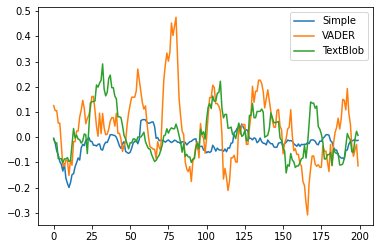

In [26]:
# Replace with your novel
# The number 500 worked okay for the Brothers Karamazov, but try a few values for your own novel
# to get a feel for what is useful to you.
plot_sentiments({'Simple': novel_simples['AliceInWonderLand_Carroll_Hamilton.txt'], 
                 'VADER': novel_vaders['AliceInWonderLand_Carroll_Hamilton.txt'], 
                 'TextBlob': novel_textblobs['AliceInWonderLand_Carroll_Hamilton.txt']}, 
                200, "upper right")

1. How similar are the sentiment plots for the analyzers?
They are all pretty similar. I will say that the ratios are the same for the plots, but the magnitudes of the sentiment are different. Vader has the most extreme magnitude and is a more extreme version of the other two. Textblob is a nice medium between the two. Not too extreme, but definitely more than the simple. The simple has the least extreme scores and most of the numbers stayed close to 0.

2. How did you determine a satisfactory window size? 
I chose 1000 because I fiddled around with it with scores from 50-1000000 and saw what worked best for Alice in Wonderland.200 was the perfect window where it fit everything on the screen and was not too conjested and conglomerated

3. To what degree does the sentiment graph track with critical passages and plot points of your book?
I think I would say that it has a medium degree of tracking critical passages. You can see there are spikes in the scores in the middle of the book, but I feel like Alice in Wonderland is a book of nonstop action so it's hard to highlight major points throughout the whole book.

## Novel Sentence Lengths

Run the code below to display a table of the number of sentences in the novels in the corpus. Then run the following code block, which will show a dendrogram of similarities of numbers of sentences.

In [27]:
novel_sentence_lengths = {filename: len(sentences) for filename, sentences in novel_sentences.items()}
novel_sentence_table = [[filename, n] for filename, n in novel_sentence_lengths.items()]
novel_sentence_table.sort(key=lambda p: -p[1])
show_markdown_table(['Novel', 'Number of Sentences'], novel_sentence_table)

| Novel | Number of Sentences |
| ----: | ------------------: |
| CombinedLOTRFixed.txt | 35557 |
| karamazov_dostoevsky_ferrer.txt | 28643 |
| dostoyevsky_crime_punishment_mason.txt | 20666 |
| Poisonwood_Kingsolver_Velazquez.txt | 12412 |
| master_margarita_walker.txt | 12348 |
| Dracula_Washum.txt | 9748 |
| Beloved_Morrison_Kamanga.txt | 8352 |
| TwentyThousandLeaguesTMGB.txt | 6979 |
| 1984 by George Orwell - Jory Fulmer.txt | 6748 |
| Adventures_of_Huckleberry_Finn_Polka.txt | 6561 |
| TheHobbit.txt | 6030 |
| thingstheycaried_obrien_johnson.txt | 5297 |
| Twain_TomSawyer_Quarles.txt | 5218 |
| shv_vonnegut_morris.txt | 4226 |
| Hamlet_DeHaan.txt | 4189 |
| things_fall_apart_chinua_achebe_ketsia.txt | 3930 |
| frankenstein_shelly_qualls.txt | 3574 |
| PeterPan.txt | 3561 |
| gatsby_booher.txt | 3557 |
| TheJungleBook_Wharton.txt | 3409 |
| Heart_Darkness_Conrad_Moslander.txt | 2895 |
| AliceInWonderLand_Carroll_Hamilton.txt | 1847 |
| Animal_Farm.txt | 1704 |
| jekyll_hyde_stevenson_lockert.txt | 1569 |


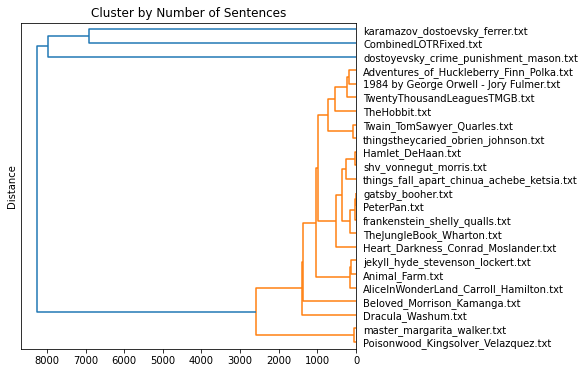

In [28]:
sizes = [[p[1]] for p in novel_sentence_table]
names = [p[0] for p in novel_sentence_table]
clusters = linkage(sizes)

plt.figure(figsize=(6, 6))
dendrogram(clusters, labels=names, orientation="left")
plt.title("Cluster by Number of Sentences")
plt.ylabel("Distance")
plt.show()

# Comparing Novels by Sentiment Dynamics

Examine the clustering of novels by number of sentences. 

Identify two other novels for which you would like to compare the sentiment dynamics to those of your novel. These comparisons are most effective when comparing to novels of similar length.

Call `plot_sentiments()` to graph the dynamics of the three novels with each of the three sentiment analyzers we have been using for the novels.

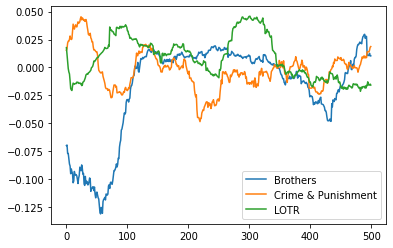

In [29]:
# Adjust for your novel and comparisons. Also use your preferred number of buckets.
plot_sentiments({'Brothers': novel_simples['karamazov_dostoevsky_ferrer.txt'], 
                 'Crime & Punishment': novel_simples['dostoyevsky_crime_punishment_mason.txt'],
                 'LOTR': novel_simples['CombinedLOTRFixed.txt']}, 
                500, "lower right")


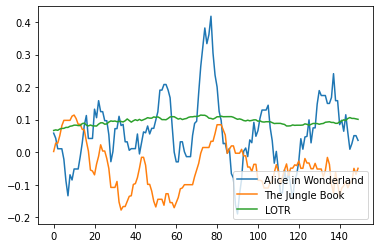

In [30]:
# Adjust for your novel and comparisons. Also use your preferred number of buckets.
plot_sentiments({'Alice in Wonderland': novel_vaders['AliceInWonderLand_Carroll_Hamilton.txt'], 
                 'The Jungle Book': novel_vaders['TheJungleBook_Wharton.txt'],
                 'LOTR': novel_vaders['CombinedLOTRFixed.txt']}, 
                150, "lower right")

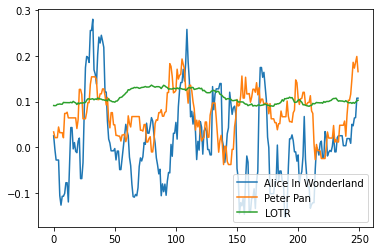

In [31]:
# Adjust for your novel and comparisons. Also use your preferred number of buckets.
plot_sentiments({'Alice In Wonderland': novel_textblobs['AliceInWonderLand_Carroll_Hamilton.txt'], 
                 'Peter Pan': novel_textblobs['PeterPan.txt'],
                 'LOTR': novel_textblobs['CombinedLOTRFixed.txt']}, 
                250, "lower right")

## Analysis

1. Read a summary of each of the other two novels serving as comparisons. (You may use your Lab 4 solution for this purpose, or find a summary online.) What key aspects of those stories are reflected in their sentiment dynamics?

Peter Pan is very similar to Alice in Wonderland because they both involve children falling asleep and ending up in a fictional place. The main characters have to fight off a tyrannical figure for survival while learning a lot in the process. Very similar plots

The Jungle Book is similar to Alice in Wonderland because they are both fictional stories with talking animals and similar plots. Shere Khan and Captain hook are very similar villains with very similar backgrounds who are looking to destroy the main characters.

2. What similarities in the plots of the stories do you see reflected in convergences of the sentiment dynamics? What differences in the plots do you see reflected in divergences in the sentiment dynamics? Give at least one example of a convergence and divergence between your novel and each of the two novels with which you are comparing it.

Like I said above, all three books have similar plots and you can see on the graphs that the climaxes of all of the books line up at the same time. 

Peter Pan: For convergences both have the main plot of escapism from the boring world into a fictional place. These book highlight adventure, fun, and youthfulness, which can cause positive sentiments in readers. For example, Alice falls down the rabbit hole into Wonderland, while Peter Pan leads Wendy and her brothers to Neverland.  For Divergences, Alice in Wonderland is a fictional setting trying to get back to reality. On the other hand, Peter Pan focuses on eternal youth. This contrast in tone can lead to divergences in sentiment dynamics. While both stories may evoke feelings of wonder, the type and intensity of emotions might differ due to the varying tones

Jungle Book: For convergences, both novels have main characters who find themselves in unfamiliar environment with talking animals. Both stories focus on self-discovery and survival, which cuses strong emotion from the reader. The settings and the conflicts are different. While Wonderland magical while the jungle is a scary place. This contrast in setting and tone can lead to divergent sentiment dynamics. 

# Summative Questions

1. Overall, based on both the poems and novels, what are the strengths and weaknesses of each of the sentiment analysis tools we examined?

The sentiment analysis tools are good at analyzing and scoring concrete emotion in a sentence, such as "I am happy". By taking the value of each word, a total score is returned . A weakness of the sentiment analysis we are using is that it is only as good as the data it is trained on, can't understand convoluted sentences (sarcasm, witty statements, double meanings), and I feel like metaphors would throw off the score as well.

2. What new insights has sentiment analysis enabled for you with regard to your poem and novel?

It has brought to my eyes that poems and novels can be identified and labeled as positive or negative based on a score. It has reinforced what I believed that Alice in Wonderland has an overall negative conotation. It is interesting because Alice in Wonderland is a children's book with a lot of positive message, but also has a lot of creepy characters and "negative" things happen in the book. 

3. In what scenarios beyond literary analysis might you apply sentiment analysis? Why?

Sentiment analysis can be used in a restricted search engine or social media regulation (to an extent). Some search engines made for kids prevent anything bad or non-kid worthy from being searched and I feel like if you use a sentiment analyzer could be used to analyze the words that are searched and determine if it is appropriate for kids. Social media also uses something similar to sentiment analysis by regulating hateful and innappropriate words that are attempted to be posted.